Struktur data graf dan algoritma

In [ ]:
!pip install networkx matplotlib

In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
  distances = {node: float('inf') for node in graph}
  distances[start] = 0
  previous = {node: None for node in graph}
  queue = [(0, start)]

  while queue:
    current_distance, current_node = heapq.heappop(queue)

    for neighbor, weigh in graph[current_node].items():
      distance = current_distance + weigh
      if distance < distances[neighbor]:
        distances[neighbor] = distance
        previous[neighbor] = current_node
        heapq.heappush(queue, (distance, neighbor))

  return distances, previous

Fungsi rekontruksi jalur

In [ ]:
def get_path(previous, target):
  path = []
  while target is not None:
    path.insert(0, target)
    target = previous[target]
  return path

Visualisasi dengan networkx dan pathlib

In [ ]:
def visualize_graph(graph, path=None):
  G = nx.DiGraph()

  for node in graph:
    for neighbor, weight in graph[node].items():
      G.add_edge(node, neighbor, weight=weight)

  pos = nx.spring_layout(G)
  edge_labels = nx.get_edge_attributes(G, 'weight')

  plt.figure(figsize=(8,6))
  nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

  # Garis tebal untuk jalur terpendek
  if path and len(path) > 1:
    path_edge = list(zip(path, path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edge, edge_color='red', width=3)

    plt.title("Visualisasi Graph dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

Penggunaan lengkap

Jarak dari A ke Z: 14
Jalur: A -> B -> D -> E -> Z


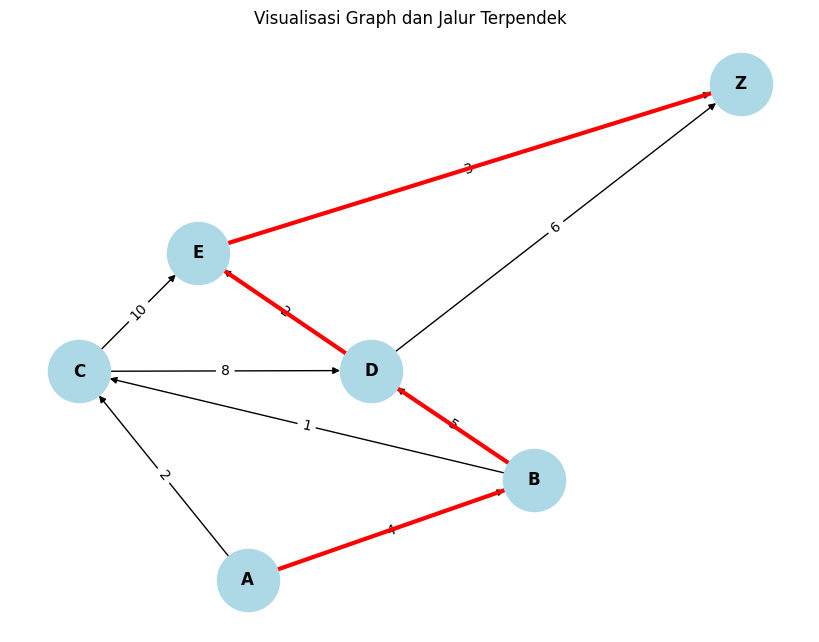

In [ ]:
# Definisi grap
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {}
}

#  Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)

# Rekontruksi jalur
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

# Visualisasi
visualize_graph(graph, path=shortest_path)

Tugas

Jarak dari A ke Z: 7
Jalur: A -> C -> F -> Z


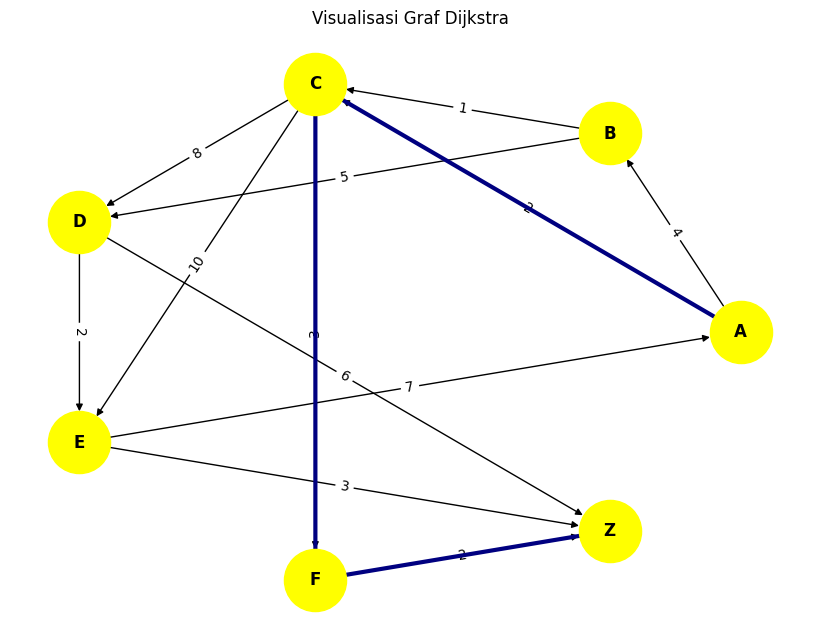

In [3]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}
    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous


def get_path(previous, target):
    path = []

    while target is not None:
        path.insert(0, target)
        target = previous[target]

    return path


def visualize_graph(graph, path=None):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.circular_layout(G)

    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color='yellow',
        node_size=2000,
        font_weight='bold',
        arrows=True
    )

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels
    )

# Menandai jalur terpendek dengan warna merah
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=path_edges,
            edge_color='navy',
            width=3
        )

    plt.title("Visualisasi Graf Dijkstra")
    plt.axis('off')
    plt.show()

# Memiliki siklus dan simpul baru F

graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10, 'F': 3},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'A': 7},
    'F': {'Z': 2},
    'Z': {}
}

# Menjalankan algoritma Dijkstra
start_node = 'A'
end_node = 'Z'

distances, previous = dijkstra_with_paths(graph, start_node)

# Rekonstruksi jalur terpendek
shortest_path = get_path(previous, end_node)

print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

# Visualisasi graf
visualize_graph(graph, path=shortest_path)